In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def gamma_correction(image, c, gamma):
    # normalize image
    I_norm = image.astype('float32') / 255.0
    
    output = c * (I_norm ** gamma)
    
    output = np.clip(output * 255, 0, 255).astype('uint8')
    
    return output

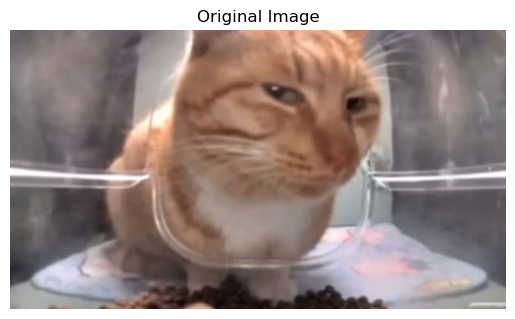

In [15]:
img = cv2.imread("/Users/230150/Downloads/cat.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

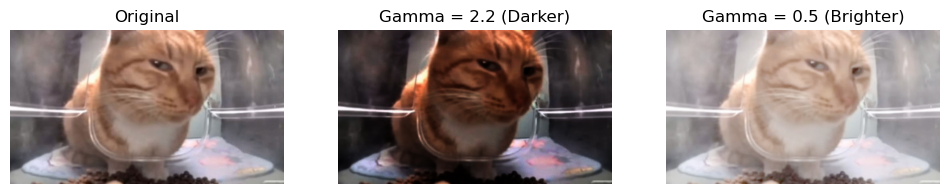

In [16]:
gamma_dark = gamma_correction(img, c=1, gamma=2.2)
gamma_bright = gamma_correction(img, c=1, gamma=0.5)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gamma_dark)
plt.title("Gamma = 2.2 (Darker)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gamma_bright)
plt.title("Gamma = 0.5 (Brighter)")
plt.axis("off")

plt.show()

Reason for choosing 𝛾
 - 𝛾 < 1 → brightens dark images.
 - 𝛾 > 1 → reduces brightness of overexposed images.
 - Value selected depending on whether image looks dark or too bright.

In [17]:
I_norm = img.astype('float32') / 255.0

#saving 
cv2.imwrite("normalized.png", (I_norm*255).astype('uint8'))

True

In [18]:
def contrast_stretching(image, smin, smax):
    
    rmin = np.min(image)
    rmax = np.max(image)
    
    stretched = ((image - rmin) / (rmax - rmin)) * (smax - smin) + smin
    
    return np.clip(stretched, 0, 255).astype('uint8')

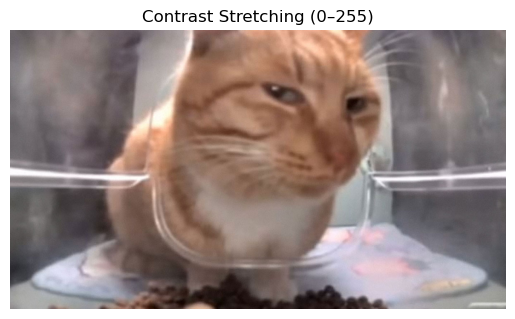

In [19]:
cs1 = contrast_stretching(img, 0, 255)

plt.imshow(cs1)
plt.title("Contrast Stretching (0–255)")
plt.axis("off")
plt.show()

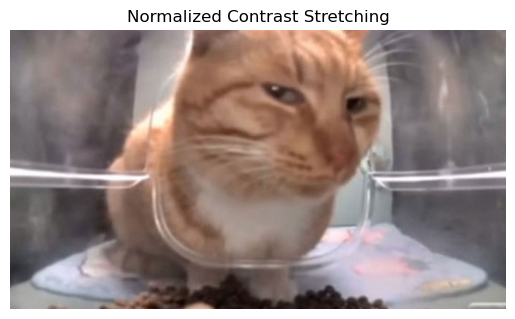

In [20]:
img_norm = img.astype('float32') / 255.0

cs2 = ((img_norm - img_norm.min()) /
      (img_norm.max() - img_norm.min())) * (1 - 0) + 0

plt.imshow(cs2)
plt.title("Normalized Contrast Stretching")
plt.axis("off")
plt.show()

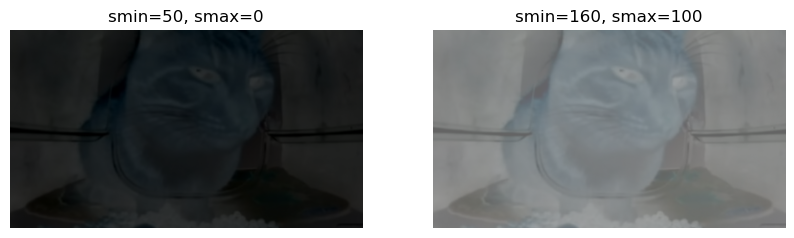

In [21]:
cs_a = contrast_stretching(img, 50, 0)
cs_b = contrast_stretching(img, 160, 100)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cs_a)
plt.title("smin=50, smax=0")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cs_b)
plt.title("smin=160, smax=100")
plt.axis("off")

plt.show()

Observations (write in report)

Normalization impact
 - Makes intensity range consistent.
 - Prevents overflow errors.
 - Produces smoother contrast adjustment.

Different (smin, smax)
 • Smaller range → lower contrast.
 • Wider range → stronger contrast.
 • Reversed values invert brightness appearance.

Part 1: Gamma Correction

Gamma correction is a nonlinear intensity transformation based on the formula:

T(r) = c r^\gamma

where r is the input intensity, c is a constant, and γ (gamma) controls brightness.

A Python function named gamma_correction was created. First, the image was normalized by dividing pixel values by 255. After normalization, the image intensity was raised to the power of gamma. Finally, the result was converted back to the range 0–255.

Different gamma values were tested:
 • γ < 1 made dark images brighter.
 • γ > 1 reduced brightness and improved very bright images.

The gamma value was selected depending on the appearance of each image. Dark images required smaller gamma values, while bright images required larger values.

During the experiment, saving the normalized image caused a problem because OpenCV saves images in the 0–255 range. The issue was solved by multiplying the normalized image by 255 and converting it to uint8.


Part 2: Contrast Stretching

Contrast stretching is a linear transformation used to expand the intensity range of an image. It improves images that look faded or have low contrast.

A function called contrast_stretching was implemented. The minimum and maximum intensity values of the image were calculated, and then pixel values were stretched using the contrast stretching formula.

The transformation was applied to both non-normalized and normalized images.

Observations
 • Contrast stretching increased visibility of details.
 • Normalized images produced smoother and more stable results.
 • Changing values of s_{min} and s_{max} affected contrast:
 • Larger range increased contrast.
 • Smaller range reduced contrast.
 • Reversed values changed brightness appearance.